In [4]:
import os
from google.colab import drive
drive.mount('/content/drive')
data_path = "/content/drive/My Drive"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
!ls "/content/drive/My Drive/ECG_dataset/preprocessed_data"

sym_all.csv  sym_all.pkl  X_all_normalized.npy


In [6]:
import numpy as np
import os
import pickle
from collections import Counter
from sklearn.preprocessing import LabelEncoder
import gc

# === Set your GAN generation path ===
gen_extract_path = '/content/drive/MyDrive/ECG_dataset'

# === GAN Synthetic File Mapping for Classes 2–13 ===
synthetic_files = {
    'S': os.path.join(gen_extract_path, 'generated_data/generated_S_signals.npy'),
    'J': os.path.join(gen_extract_path, 'generated_data/generated_JJ_signals.npy'),
    'A': os.path.join(gen_extract_path, 'generated_data/generated_AA_signals.npy'),
    'e': os.path.join(gen_extract_path, 'generated_data/generated_e_signals.npy'),
    'f': os.path.join(gen_extract_path, 'generated_data/generated_f_signals.npy'),
    'F': os.path.join(gen_extract_path, 'generated_data/generated_FF_signals.npy'),
    'j': os.path.join(gen_extract_path, 'generated_data/generated_j_signals.npy'),
    '/': os.path.join(gen_extract_path, 'generated_data/generated_o_signals.npy'),
    'R': os.path.join(gen_extract_path, 'generated_data/generated_R_signals.npy'),
    'V': os.path.join(gen_extract_path, 'generated_data/generated_V_signals.npy'),
    'E': os.path.join(gen_extract_path, 'generated_data/generated_EE_signals.npy'),
    'a': os.path.join(gen_extract_path, 'generated_data/generated_a_signals.npy'),
}

# === ECG Class Definitions ===
ECG_classes = ['N', 'L', 'R', 'V', '/', 'A', 'f', 'F', 'j', 'a', 'E', 'J', 'e', 'S']
label_encoder = LabelEncoder()
label_encoder.classes_ = np.array(ECG_classes)

# === Load Original Preprocessed Data ===
X_all_normalized = np.load('/content/drive/My Drive/ECG_dataset/preprocessed_data/X_all_normalized.npy')
with open('/content/drive/My Drive/ECG_dataset/preprocessed_data/sym_all.pkl', 'rb') as f:
    sym_all = pickle.load(f)

Y_all = label_encoder.transform(sym_all)

# === Initialize combined arrays ===
X_all_combined = []
Y_all_combined = []

# === Iterate over all classes 0–13 ===
for symbol in ECG_classes:
    class_index = label_encoder.transform([symbol])[0]

    # Get original beats for this class
    mask = (Y_all == class_index)
    X_orig = X_all_normalized[mask]
    Y_orig = np.full(len(X_orig), class_index)

    # Append original data
    X_combined_class = [X_orig]
    Y_combined_class = [Y_orig]

    # If GAN data exists for this class, append it
    if symbol in synthetic_files:
        X_gen = np.load(synthetic_files[symbol])
        Y_gen = np.full(len(X_gen), class_index)
        X_combined_class.append(X_gen)
        Y_combined_class.append(Y_gen)
        del X_gen, Y_gen
        gc.collect()

    # Stack and append to final list
    X_all_combined.append(np.vstack(X_combined_class))
    Y_all_combined.append(np.hstack(Y_combined_class))

    # Cleanup
    del mask, X_orig, Y_orig, X_combined_class, Y_combined_class
    gc.collect()

# === Cleanup raw data ===
del X_all_normalized, sym_all, Y_all
gc.collect()

# === Final Combine ===
X_final = np.vstack(X_all_combined)
Y_final = np.hstack(Y_all_combined)

# Final Cleanup
del X_all_combined, Y_all_combined
gc.collect()

# === Summary Output ===
print("✅ Final combined shape:", X_final.shape, Y_final.shape)
print("✅ Final class distribution:", Counter(Y_final))

✅ Final combined shape: (178847, 2160) (178847,)
✅ Final class distribution: Counter({np.int64(0): 74795, np.int64(1): 8052, np.int64(2): 8000, np.int64(3): 8000, np.int64(4): 8000, np.int64(5): 8000, np.int64(6): 8000, np.int64(7): 8000, np.int64(8): 8000, np.int64(9): 8000, np.int64(10): 8000, np.int64(11): 8000, np.int64(12): 8000, np.int64(13): 8000})


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import gc
import time
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import backend as K

# === Final Data ===
num_classes = 14
X_final_cnn = X_final.reshape((X_final.shape[0], X_final.shape[1], 1))
Y_final_cat = to_categorical(Y_final, num_classes=num_classes)

# === Stratified 5-Fold CV ===
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc_per_fold = []
precision_per_fold = []
recall_per_fold = []
f1_per_fold = []
time_per_fold = []
all_histories = []
fold_no = 1


--- Fold 1 ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 94s 78ms/step - accuracy: 0.8451 - loss: 0.5958 - val_accuracy: 0.9711 - val_loss: 0.1024
Epoch 2/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 131s 73ms/step - accuracy: 0.9700 - loss: 0.1110 - val_accuracy: 0.9849 - val_loss: 0.0540
Epoch 3/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 84s 75ms/step - accuracy: 0.9797 - loss: 0.0736 - val_accuracy: 0.9870 - val_loss: 0.0504
Epoch 4/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 139s 72ms/step - accuracy: 0.9844 - loss: 0.0535 - val_accuracy: 0.9884 - val_loss: 0.0467
Epoch 5/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 83s 74ms/step - accuracy: 0.9872 - loss: 0.0443 - val_accuracy: 0.9895 - val_loss: 0.0405
Epoch 6/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 140s 72ms/step - accuracy: 0.9893 - loss: 0.0348 - val_accuracy: 0.9880 - val_loss: 0.0446
Epoch 7/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 81s 72ms/step - accuracy: 0.9894 - loss: 0.0335 - val_accuracy: 0.9911 - val_loss: 0.0384
Epoch 8/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 84s 74ms/step - accuracy: 0.992

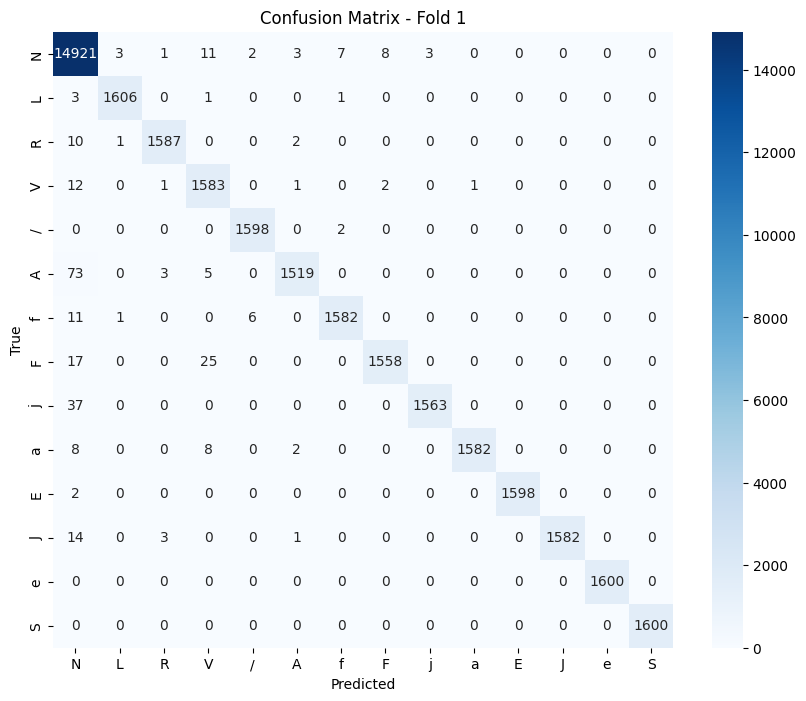


--- Fold 2 ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 89s 77ms/step - accuracy: 0.8183 - loss: 0.7075 - val_accuracy: 0.9574 - val_loss: 0.1454
Epoch 2/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 138s 75ms/step - accuracy: 0.9566 - loss: 0.1535 - val_accuracy: 0.9809 - val_loss: 0.0715
Epoch 3/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 81s 73ms/step - accuracy: 0.9754 - loss: 0.0888 - val_accuracy: 0.9856 - val_loss: 0.0522
Epoch 4/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 84s 75ms/step - accuracy: 0.9818 - loss: 0.0651 - val_accuracy: 0.9862 - val_loss: 0.0519
Epoch 5/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 142s 74ms/step - accuracy: 0.9846 - loss: 0.0547 - val_accuracy: 0.9871 - val_loss: 0.0453
Epoch 6/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 83s 74ms/step - accuracy: 0.9880 - loss: 0.0410 - val_accuracy: 0.9870 - val_loss: 0.0451
Epoch 7/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 140s 72ms/step - accuracy: 0.9888 - loss: 0.0398 - val_accuracy: 0.9890 - val_loss: 0.0396
Epoch 8/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 82s 73ms/step - accuracy: 0.990

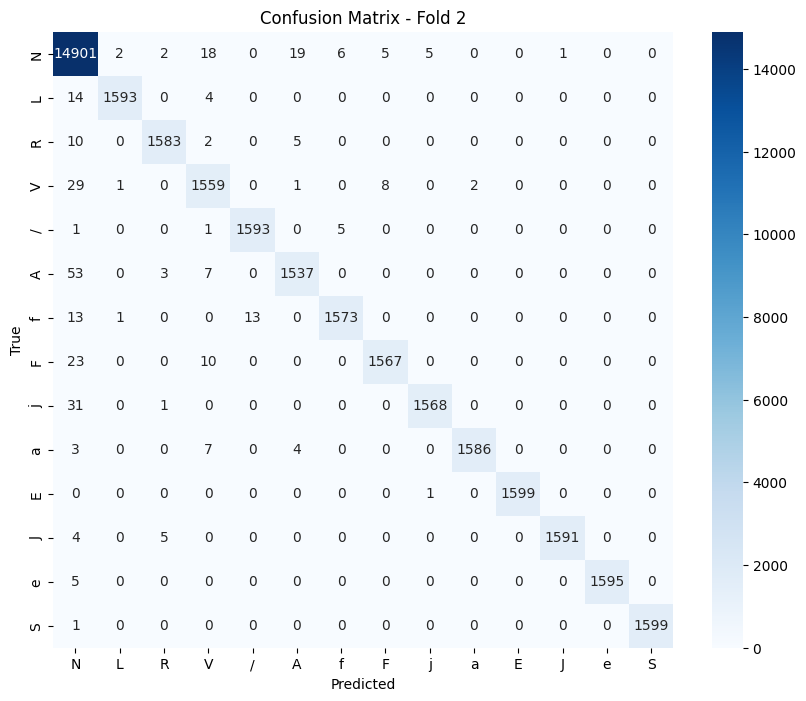


--- Fold 3 ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 92s 78ms/step - accuracy: 0.8300 - loss: 0.6608 - val_accuracy: 0.9681 - val_loss: 0.1182
Epoch 2/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 137s 75ms/step - accuracy: 0.9634 - loss: 0.1336 - val_accuracy: 0.9794 - val_loss: 0.0776
Epoch 3/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 142s 75ms/step - accuracy: 0.9736 - loss: 0.0925 - val_accuracy: 0.9822 - val_loss: 0.0701
Epoch 4/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 139s 73ms/step - accuracy: 0.9793 - loss: 0.0705 - val_accuracy: 0.9870 - val_loss: 0.0525
Epoch 5/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 84s 74ms/step - accuracy: 0.9837 - loss: 0.0569 - val_accuracy: 0.9881 - val_loss: 0.0466
Epoch 6/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 142s 75ms/step - accuracy: 0.9857 - loss: 0.0469 - val_accuracy: 0.9881 - val_loss: 0.0497
Epoch 7/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 142s 74ms/step - accuracy: 0.9876 - loss: 0.0403 - val_accuracy: 0.9884 - val_loss: 0.0462
Epoch 8/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 140s 72ms/step - accuracy: 0.

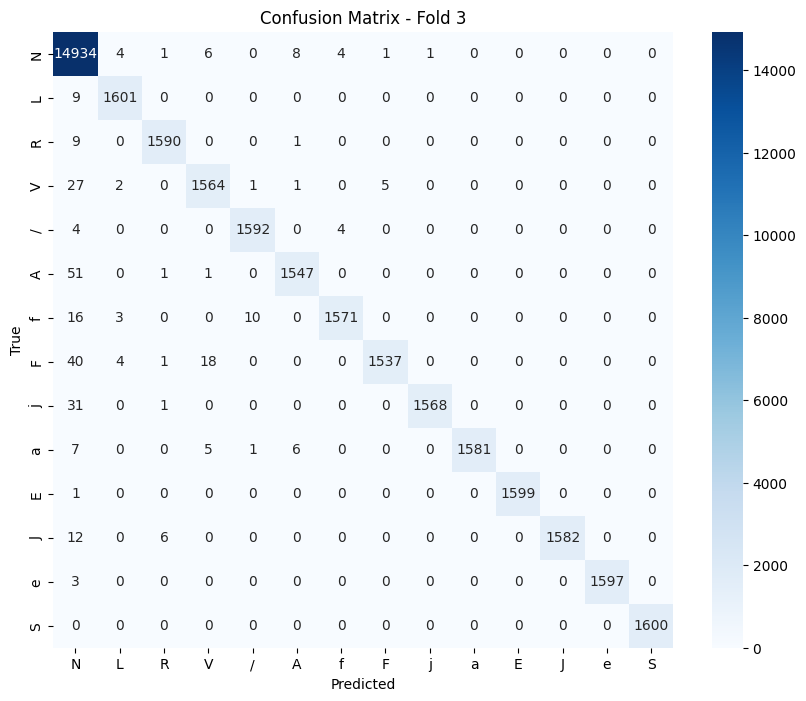


--- Fold 4 ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 88s 75ms/step - accuracy: 0.8240 - loss: 0.6853 - val_accuracy: 0.9676 - val_loss: 0.1206
Epoch 2/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 81s 73ms/step - accuracy: 0.9589 - loss: 0.1519 - val_accuracy: 0.9826 - val_loss: 0.0671
Epoch 3/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 84s 75ms/step - accuracy: 0.9736 - loss: 0.0933 - val_accuracy: 0.9864 - val_loss: 0.0533
Epoch 4/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 84s 75ms/step - accuracy: 0.9795 - loss: 0.0729 - val_accuracy: 0.9870 - val_loss: 0.0501
Epoch 5/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 139s 72ms/step - accuracy: 0.9818 - loss: 0.0622 - val_accuracy: 0.9866 - val_loss: 0.0500
Epoch 6/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 84s 74ms/step - accuracy: 0.9853 - loss: 0.0485 - val_accuracy: 0.9890 - val_loss: 0.0424
Epoch 7/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 139s 71ms/step - accuracy: 0.9876 - loss: 0.0431 - val_accuracy: 0.9900 - val_loss: 0.0416
Epoch 8/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 82s 72ms/step - accuracy: 0.9898

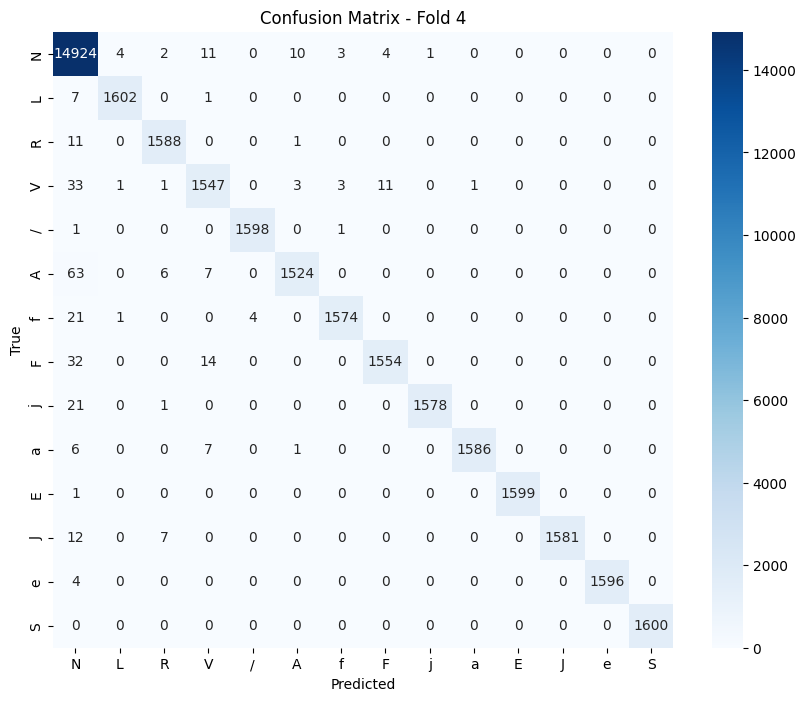


--- Fold 5 ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 90s 77ms/step - accuracy: 0.8320 - loss: 0.6572 - val_accuracy: 0.9710 - val_loss: 0.1060
Epoch 2/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 136s 73ms/step - accuracy: 0.9640 - loss: 0.1334 - val_accuracy: 0.9798 - val_loss: 0.0717
Epoch 3/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 84s 75ms/step - accuracy: 0.9765 - loss: 0.0849 - val_accuracy: 0.9856 - val_loss: 0.0536
Epoch 4/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 142s 75ms/step - accuracy: 0.9813 - loss: 0.0656 - val_accuracy: 0.9885 - val_loss: 0.0426
Epoch 5/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 142s 75ms/step - accuracy: 0.9841 - loss: 0.0562 - val_accuracy: 0.9869 - val_loss: 0.0519
Epoch 6/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 142s 74ms/step - accuracy: 0.9871 - loss: 0.0434 - val_accuracy: 0.9897 - val_loss: 0.0412
Epoch 7/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 140s 72ms/step - accuracy: 0.9884 - loss: 0.0397 - val_accuracy: 0.9894 - val_loss: 0.0424
Epoch 8/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 84s 74ms/step - accuracy: 0.9

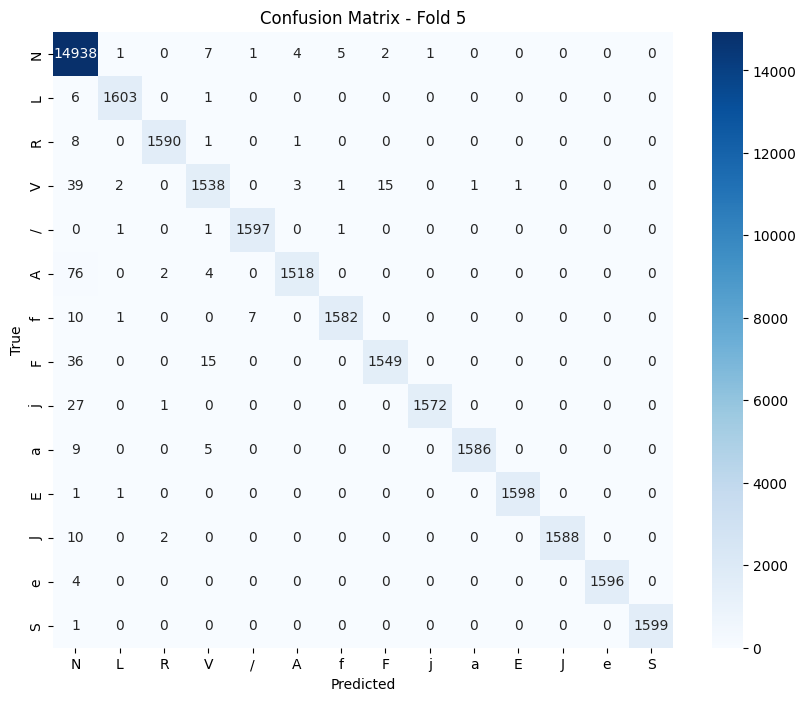


✅ Total training time for 5 folds: 8026.51 seconds


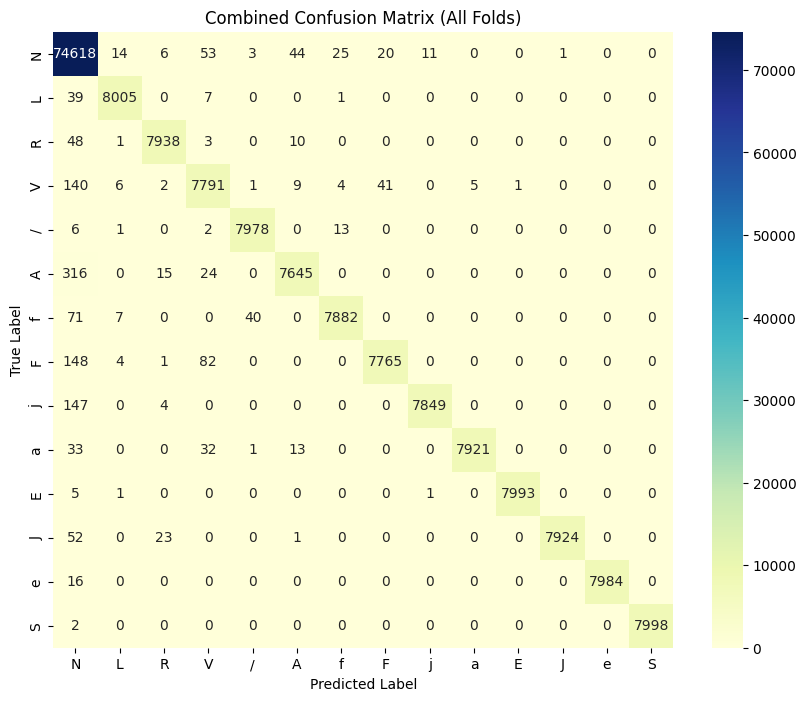

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import time
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (classification_report, accuracy_score,
                             precision_score, recall_score, f1_score, confusion_matrix)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import backend as K

# === ECG Classes ===
ECG_classes = ['N', 'L', 'R', 'V', '/', 'A', 'f', 'F', 'j', 'a', 'E', 'J', 'e', 'S']
num_classes = len(ECG_classes)

# === Prepare Final Data ===
X_final_cnn = X_final.reshape((X_final.shape[0], X_final.shape[1], 1))
Y_final_cat = to_categorical(Y_final, num_classes=num_classes)

# === Stratified 5-Fold CV ===
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc_per_fold = []
precision_per_fold = []
recall_per_fold = []
f1_per_fold = []
time_per_fold = []
all_histories = []
all_y_true = []
all_y_pred = []
fold_no = 1

# Start total timer
total_start_time = time.time()

for train_idx, val_idx in skf.split(X_final_cnn, Y_final):
    print(f"\n--- Fold {fold_no} ---")

    X_train, X_val = X_final_cnn[train_idx], X_final_cnn[val_idx]
    y_train_cat, y_val_cat = Y_final_cat[train_idx], Y_final_cat[val_idx]
    y_val_true = Y_final[val_idx]

    # Define model
    model = Sequential([
        Conv1D(filters=64, kernel_size=7, activation='relu', input_shape=(X_train.shape[1], 1)),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=128, kernel_size=5, activation='relu'),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=256, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Start fold timer
    start_time = time.time()

    # Train model
    history = model.fit(
        X_train, y_train_cat,
        epochs=15,
        batch_size=128,
        validation_data=(X_val, y_val_cat),
        verbose=1
    )

    # End fold timer
    end_time = time.time()
    fold_time = end_time - start_time
    time_per_fold.append(fold_time)
    all_histories.append(history.history)

    # Evaluate
    y_pred = np.argmax(model.predict(X_val), axis=1)

    acc = accuracy_score(y_val_true, y_pred)
    prec = precision_score(y_val_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_val_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_val_true, y_pred, average='macro', zero_division=0)

    acc_per_fold.append(acc)
    precision_per_fold.append(prec)
    recall_per_fold.append(rec)
    f1_per_fold.append(f1)

    all_y_true.append(y_val_true)
    all_y_pred.append(y_pred)

    print(f"Fold {fold_no} Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f} | Recall: {rec:.4f} | F1-score: {f1:.4f}")
    print(f"Training time: {fold_time:.2f} seconds")
    print("Classification Report:")
    print(classification_report(y_val_true, y_pred, target_names=ECG_classes))

    # Confusion matrix per fold
    cm = confusion_matrix(y_val_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=ECG_classes, yticklabels=ECG_classes)
    plt.title(f'Confusion Matrix - Fold {fold_no}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # Cleanup
    del model
    K.clear_session()
    gc.collect()
    fold_no += 1

# End total timer
total_end_time = time.time()
total_duration = total_end_time - total_start_time

print(f"\n✅ Total training time for 5 folds: {total_duration:.2f} seconds")

# === Combined Confusion Matrix ===
combined_true = np.concatenate(all_y_true)
combined_pred = np.concatenate(all_y_pred)

cm_total = confusion_matrix(combined_true, combined_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_total, annot=True, fmt='d', cmap='YlGnBu', xticklabels=ECG_classes, yticklabels=ECG_classes)
plt.title('Combined Confusion Matrix (All Folds)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


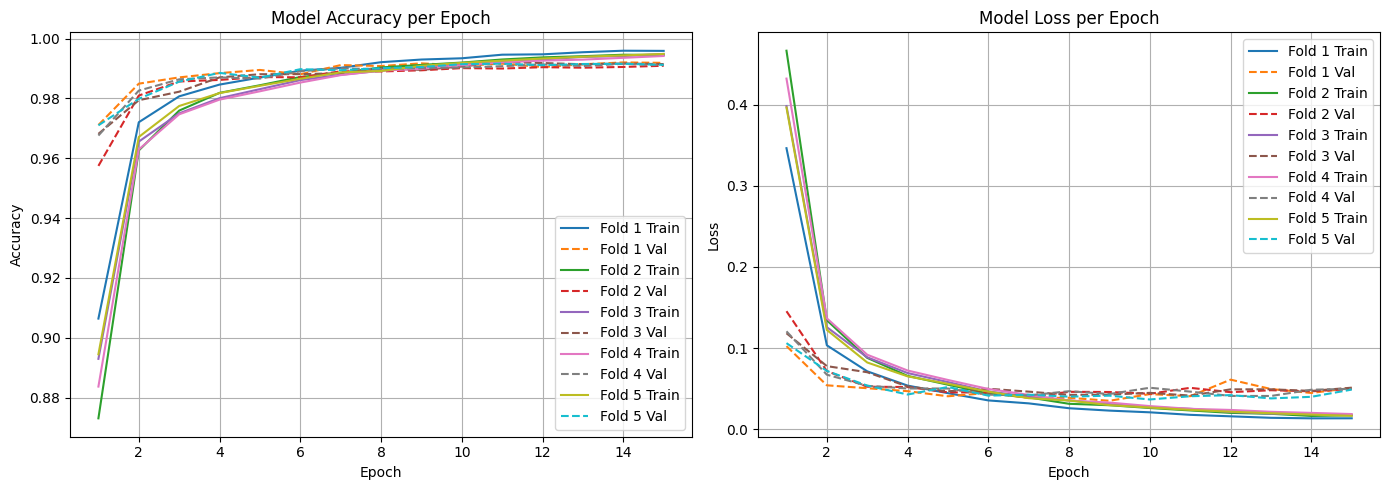

In [9]:
# === Plot Accuracy and Loss Curves ===
epochs = range(1, 16)

plt.figure(figsize=(14, 5))

# Accuracy Curves
plt.subplot(1, 2, 1)
for i, hist in enumerate(all_histories):
    plt.plot(epochs, hist['accuracy'], label=f'Fold {i+1} Train')
    plt.plot(epochs, hist['val_accuracy'], linestyle='--', label=f'Fold {i+1} Val')
plt.title('Model Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Curves
plt.subplot(1, 2, 2)
for i, hist in enumerate(all_histories):
    plt.plot(epochs, hist['loss'], label=f'Fold {i+1} Train')
    plt.plot(epochs, hist['val_loss'], linestyle='--', label=f'Fold {i+1} Val')
plt.title('Model Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

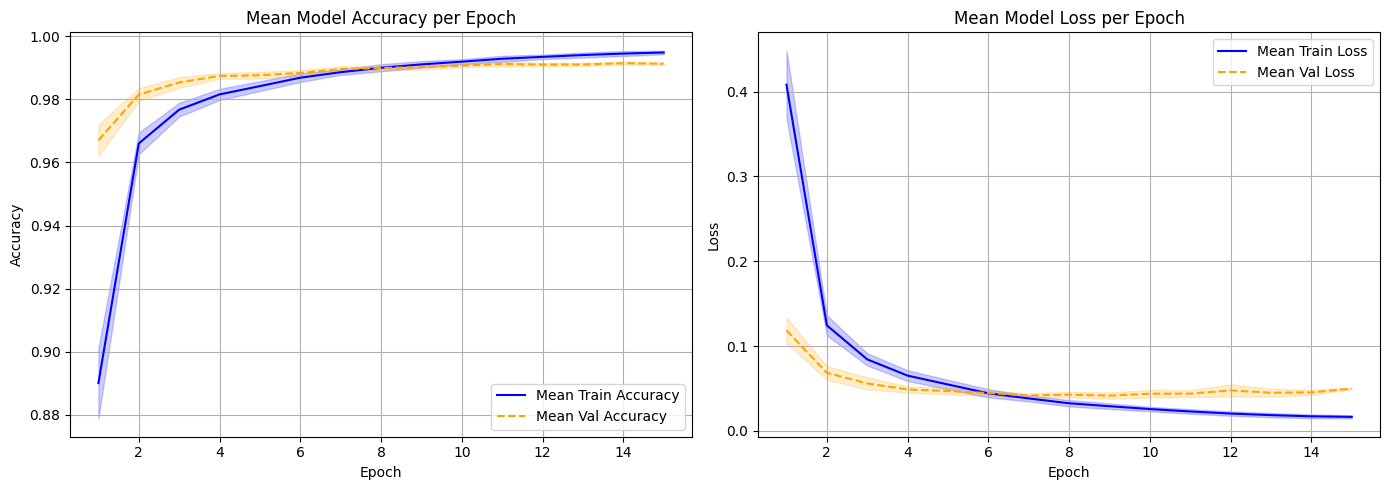

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming all_histories is a list of dicts with keys: 'accuracy', 'val_accuracy', 'loss', 'val_loss'
epochs = range(1, 16)

# Convert to arrays for easier mean calculation
num_folds = len(all_histories)
num_epochs = len(all_histories[0]['accuracy'])

accuracy = np.array([hist['accuracy'] for hist in all_histories])
val_accuracy = np.array([hist['val_accuracy'] for hist in all_histories])
loss = np.array([hist['loss'] for hist in all_histories])
val_loss = np.array([hist['val_loss'] for hist in all_histories])

# Calculate mean and standard deviation
mean_accuracy = np.mean(accuracy, axis=0)
std_accuracy = np.std(accuracy, axis=0)
mean_val_accuracy = np.mean(val_accuracy, axis=0)
std_val_accuracy = np.std(val_accuracy, axis=0)

mean_loss = np.mean(loss, axis=0)
std_loss = np.std(loss, axis=0)
mean_val_loss = np.mean(val_loss, axis=0)
std_val_loss = np.std(val_loss, axis=0)

# === Plot ===
plt.figure(figsize=(14, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs, mean_accuracy, label='Mean Train Accuracy', color='blue')
plt.fill_between(epochs, mean_accuracy - std_accuracy, mean_accuracy + std_accuracy, color='blue', alpha=0.2)
plt.plot(epochs, mean_val_accuracy, label='Mean Val Accuracy', color='orange', linestyle='--')
plt.fill_between(epochs, mean_val_accuracy - std_val_accuracy, mean_val_accuracy + std_val_accuracy, color='orange', alpha=0.2)
plt.title('Mean Model Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs, mean_loss, label='Mean Train Loss', color='blue')
plt.fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss, color='blue', alpha=0.2)
plt.plot(epochs, mean_val_loss, label='Mean Val Loss', color='orange', linestyle='--')
plt.fill_between(epochs, mean_val_loss - std_val_loss, mean_val_loss + std_val_loss, color='orange', alpha=0.2)
plt.title('Mean Model Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



=== Cross-Validation Summary ===
Fold 1: Accuracy = 0.9919, Precision = 0.9945, Recall = 0.9885, F1-score = 0.9914, Time = 1540.08 sec
Fold 2: Accuracy = 0.9909, Precision = 0.9929, Recall = 0.9878, F1-score = 0.9903, Time = 1538.32 sec
Fold 3: Accuracy = 0.9914, Precision = 0.9947, Recall = 0.9873, F1-score = 0.9910, Time = 1722.92 sec
Fold 4: Accuracy = 0.9911, Precision = 0.9942, Recall = 0.9872, F1-score = 0.9907, Time = 1421.59 sec
Fold 5: Accuracy = 0.9912, Precision = 0.9949, Recall = 0.9868, F1-score = 0.9908, Time = 1715.55 sec

Average Accuracy: 0.9913
Average Precision: 0.9942
Average Recall: 0.9875
Average F1-score: 0.9908
Total Training Time: 8026.51 seconds


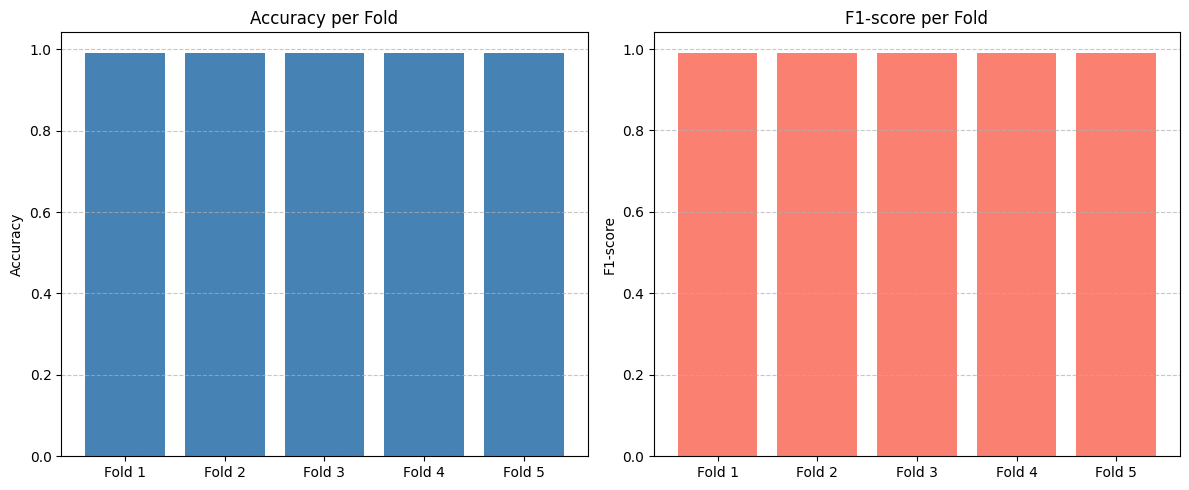

In [11]:
# === Summary ===
print("\n=== Cross-Validation Summary ===")
for i in range(5):
    print(f"Fold {i+1}: "
          f"Accuracy = {acc_per_fold[i]:.4f}, "
          f"Precision = {precision_per_fold[i]:.4f}, "
          f"Recall = {recall_per_fold[i]:.4f}, "
          f"F1-score = {f1_per_fold[i]:.4f}, "
          f"Time = {time_per_fold[i]:.2f} sec")

print(f"\nAverage Accuracy: {np.mean(acc_per_fold):.4f}")
print(f"Average Precision: {np.mean(precision_per_fold):.4f}")
print(f"Average Recall: {np.mean(recall_per_fold):.4f}")
print(f"Average F1-score: {np.mean(f1_per_fold):.4f}")
print(f"Total Training Time: {total_duration:.2f} seconds")

# === Plot Accuracy and F1-score ===
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.bar(range(1, 6), acc_per_fold, color='steelblue')
plt.xticks(range(1, 6), [f'Fold {i}' for i in range(1, 6)])
plt.ylabel('Accuracy')
plt.title('Accuracy per Fold')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# F1-score
plt.subplot(1, 2, 2)
plt.bar(range(1, 6), f1_per_fold, color='salmon')
plt.xticks(range(1, 6), [f'Fold {i}' for i in range(1, 6)])
plt.ylabel('F1-score')
plt.title('F1-score per Fold')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


/var/folders/vy/h0yt7lx97b5ct5kp84j7dk_40000gn/T/ipykernel_4041/2752401824.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=accuracy_percentages, palette="crest")


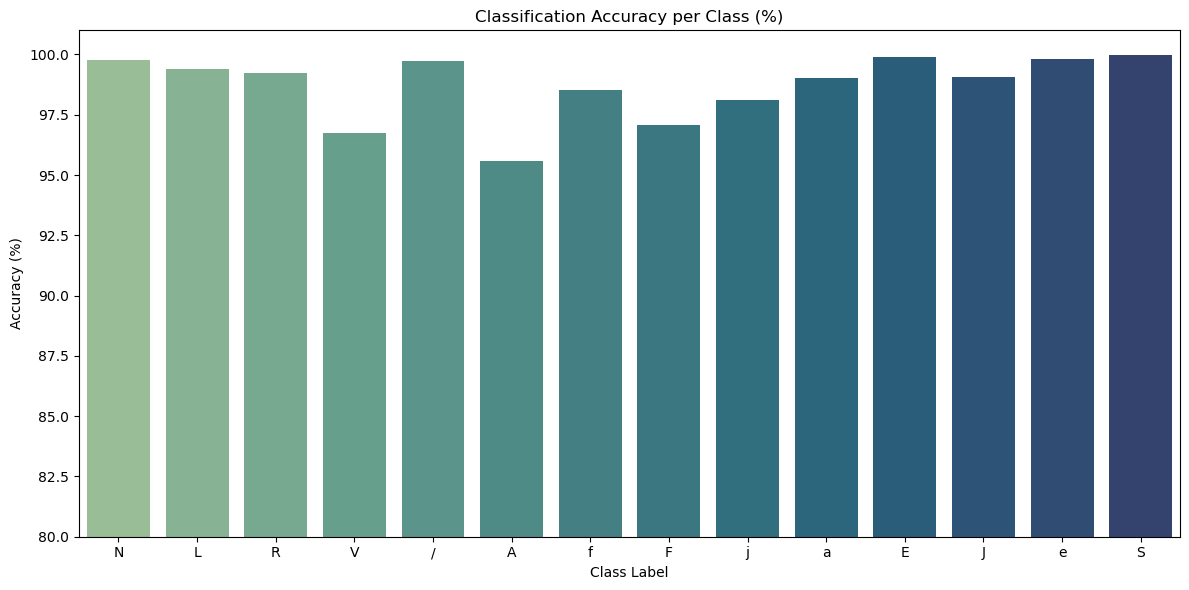

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Labels and true positive counts
labels = ['N', 'L', 'R', 'V', '/', 'A', 'f', 'F', 'j', 'a', 'E', 'J', 'e', 'S']
true_positives = [74618, 8005, 7938, 7791, 7978, 7645, 7882, 7765, 7849, 7921, 7993, 7924, 7984, 7998]

# Total actual samples per class (sum of each row in confusion matrix)
total_samples_per_class = [
    74795, 8052, 8000, 8054, 8000, 8000, 8000, 8000,
    8000, 8000, 8000, 8000, 8000, 8000
]

# Calculate accuracy percentages
accuracy_percentages = [(tp / total) * 100 for tp, total in zip(true_positives, total_samples_per_class)]

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(x=labels, y=accuracy_percentages, palette="crest")
plt.title("Classification Accuracy per Class (%)")
plt.xlabel("Class Label")
plt.ylabel("Accuracy (%)")
plt.ylim(80, 101)  # Zoomed in for better visual comparison
plt.tight_layout()
plt.show()


In [4]:
accuracy_percentages

[99.76335316531853,
 99.41629408842523,
 99.225,
 96.7345418425627,
 99.725,
 95.5625,
 98.52499999999999,
 97.0625,
 98.1125,
 99.0125,
 99.91250000000001,
 99.05000000000001,
 99.8,
 99.97500000000001]